# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Cargar el conjunto de datos Titanic
data = sns.load_dataset('titanic')

# Codificar 'sex' con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

# Codificar 'embarked' con OneHotEncoder
onehot_encoder = pd.get_dummies(
    data['embarked'],
    prefix='embarked'
)

# Combinar las columnas codificadas con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

In [3]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [4]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [6]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [9]:
# Comparación entre LabelEncoder y OneHotEncoder

print("Codificación de 'sex' con LabelEncoder:")
print(data[['sex', 'sex_label']].drop_duplicates())

print("\nCodificación de 'embarked' con OneHotEncoder:")
print(
    data[
        ['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']
    ].drop_duplicates()
)

Codificación de 'sex' con LabelEncoder:
      sex  sex_label
0    male          1
1  female          0

Codificación de 'embarked' con OneHotEncoder:
   embarked  embarked_C  embarked_Q  embarked_S
0         S       False       False        True
1         C        True       False       False
5         Q       False        True       False
61      NaN       False       False       False


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

Frecuencia original:
sex
male      577
female    314
Name: count, dtype: int64

Frecuencia después de LabelEncoder:
sex_label
0    314
1    577
Name: count, dtype: int64


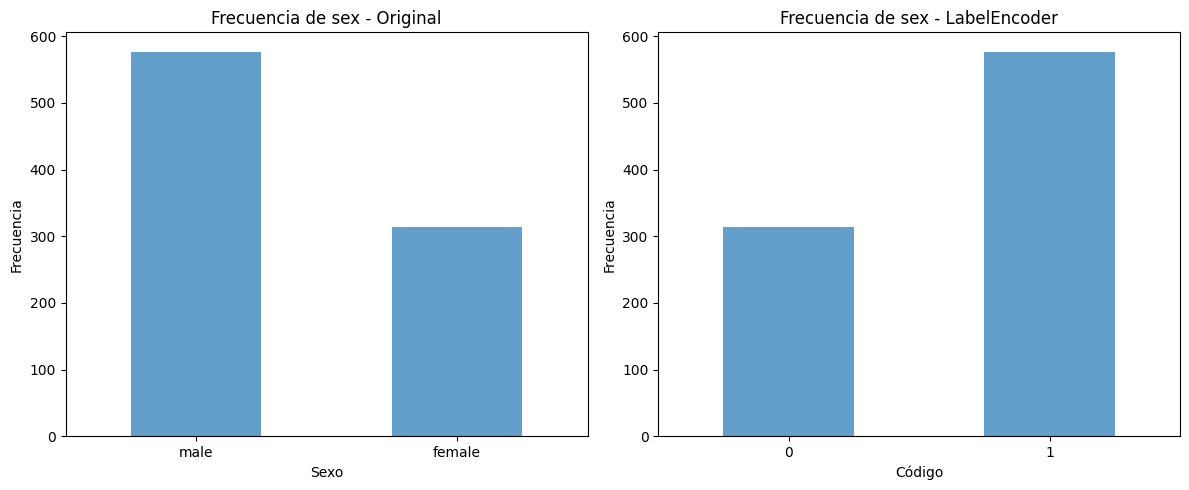

In [10]:
# Frecuencia de las categorías originales
sex_frequency = data['sex'].value_counts()

# Frecuencia después de LabelEncoder
sex_label_frequency = data['sex_label'].value_counts().sort_index()

print("Frecuencia original:")
print(sex_frequency)

print("\nFrecuencia después de LabelEncoder:")
print(sex_label_frequency)

# Crear las gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes de la codificación
sex_frequency.plot(
    kind='bar',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Frecuencia de sex - Original')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Después de LabelEncoder
sex_label_frequency.plot(
    kind='bar',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Frecuencia de sex - LabelEncoder')
axes[1].set_xlabel('Código')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [11]:
# 3. Codificar la columna 'class' utilizando OneHotEncoder

from sklearn.preprocessing import OneHotEncoder

# Crear el codificador
onehot_encoder = OneHotEncoder(sparse_output=False)

# Aplicar la codificación
class_encoded = onehot_encoder.fit_transform(data[['class']])

# Obtener los nombres de las nuevas columnas
class_columns = onehot_encoder.get_feature_names_out(['class'])

# Crear un DataFrame con las variables codificadas
class_encoded_df = pd.DataFrame(
    class_encoded,
    columns=class_columns,
    index=data.index
)

# Mostrar los primeros registros
print("Codificación OneHotEncoder de 'class':")
print(class_encoded_df.head())

Codificación OneHotEncoder de 'class':
   class_First  class_Second  class_Third
0          0.0           0.0          1.0
1          1.0           0.0          0.0
2          0.0           0.0          1.0
3          1.0           0.0          0.0
4          0.0           0.0          1.0


In [12]:
# Combinar temporalmente la columna original con la codificación
class_comparison = pd.concat(
    [data['class'], class_encoded_df],
    axis=1
)

print(class_comparison.head(10))

    class  class_First  class_Second  class_Third
0   Third          0.0           0.0          1.0
1   First          1.0           0.0          0.0
2   Third          0.0           0.0          1.0
3   First          1.0           0.0          0.0
4   Third          0.0           0.0          1.0
5   Third          0.0           0.0          1.0
6   First          1.0           0.0          0.0
7   Third          0.0           0.0          1.0
8   Third          0.0           0.0          1.0
9  Second          0.0           1.0          0.0


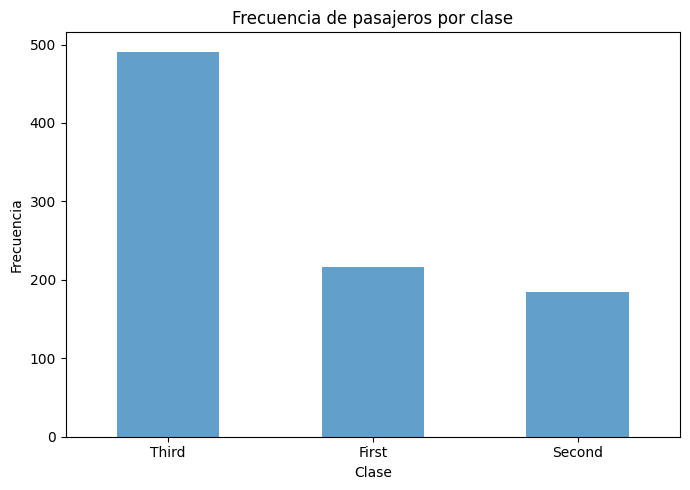

In [13]:
# Frecuencia de cada clase
class_frequency = data['class'].value_counts()

class_frequency.plot(
    kind='bar',
    figsize=(7, 5),
    alpha=0.7
)

plt.title('Frecuencia de pasajeros por clase')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [14]:
# Comparación de las codificaciones utilizadas

print("Variable 'sex' con LabelEncoder:")
print(data[['sex', 'sex_label']].drop_duplicates())

print("\nVariable 'class' con OneHotEncoder:")
print(class_encoded_df.drop_duplicates())

Variable 'sex' con LabelEncoder:
      sex  sex_label
0    male          1
1  female          0

Variable 'class' con OneHotEncoder:
   class_First  class_Second  class_Third
0          0.0           0.0          1.0
1          1.0           0.0          0.0
9          0.0           1.0          0.0


Para aplicar un modelo de aprendizaje automático elegiría principalmente OneHotEncoder para las variables categóricas nominales. Esta codificación representa cada categoría mediante una variable binaria independiente, evitando asignar valores numéricos que puedan interpretarse como una relación de orden o distancia entre las categorías.

Por ejemplo, LabelEncoder convierte las categorías en números como 0, 1 y 2, mientras que OneHotEncoder crea una columna independiente para cada categoría. Esto permite que el modelo diferencie las categorías sin asumir que una es mayor o menor que otra.

La elección también depende del tipo de variable y del algoritmo utilizado. LabelEncoder puede ser apropiado cuando las categorías tienen un orden real, mientras que OneHotEncoder resulta adecuado para variables categóricas nominales.
